# Setup

## Imports

In [1]:
import re
import random
import time
from collections import Counter
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import torch.nn.functional as F


In [4]:
from datasets import Dataset as HFDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

## Other Parameters

We set the seed to get reproducable results and use a GPU if one is available for faster training

In [5]:
def set_seed(seed: int = 42) -> None:
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [6]:
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("Using CPU")
    device = torch.device("cpu")
device

Using GPU: NVIDIA GeForce RTX 3060


device(type='cuda')

# Data Preprocessing

In [7]:
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}

train_df = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["train"], lines=True)
test_df = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["test"], lines=True)


The following cell uses regular expressions to cut out html code for embedded images and links.

In [8]:
train_df['description'] = train_df['description'].apply(lambda x: re.sub("&lt.*?/.*?&gt;", "", x))
test_df['description'] = test_df['description'].apply(lambda x: re.sub("&lt.*?/.*?&gt;", "", x))
train_df["label"] = train_df["label"] - 1
test_df["label"] = test_df["label"] - 1


Since the data already came pre-split into train and test data, we use test_train_split on the training set to create a dev validation set. This is 10% of the training dataset. We are also combining the title and the description under one variable called "text" for ease of training.

In [9]:
train_df["text"] = train_df["title"] + " " + train_df["description"]
test_df["text"] = test_df["title"] + " " + test_df["description"]

target_names = ["World", "Sports", "Business", "Sci/Tech"]
X = train_df[["text"]]
y = train_df["label"]
y_test = test_df["label"]
X_train, X_dev, y_train, y_dev = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

Creates a dictionary to be used in tokenization and training, This is needed to create the vocabulary

In [10]:
train_ds_hf = [{"text": t, "label": l} for t, l in zip(X_train["text"], y_train)]
val_ds_hf = [{"text": t, "label": l} for t, l in zip(X_dev["text"], y_dev)]
test_ds_hf = [{"text": t, "label": l} for t, l in zip(test_df["text"], test_df["label"])]

# CNN

## Tokenisation and Vocabulary

In [11]:
TOKEN_RE = re.compile(r"[A-Za-z0-9']+")

PAD = "<pad>"
UNK = "<unk>"

def tokenize(text: str):
    return TOKEN_RE.findall(text.lower())

def build_vocab(texts, min_freq: int = 2, max_size: int = 30000) -> dict:
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))
    vocab = {PAD: 0, UNK: 1}
    for word, freq in counter.most_common():
        if freq < min_freq:
            break
        if len(vocab) >= max_size:
            break
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab([d["text"] for d in train_ds_hf], min_freq=2, max_size=30000)
vocab_size = len(vocab)
PAD_IDX = vocab[PAD]
UNK_IDX = vocab[UNK]

def numericalize(tokens: list, vocab: dict) -> list:
    return [vocab.get(tok, UNK_IDX) for tok in tokens]

## Dataset and Collate

In [12]:
@dataclass
class Batch:
    x: torch.Tensor
    lengths: torch.Tensor
    y: torch.Tensor

class TextDataset(Dataset):
    def __init__(self, hf_ds: list, vocab: dict, max_len: int = 200) -> None:
        self.ds = hf_ds
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx: int):
        item = self.ds[idx]
        tokens = tokenize(item["text"])
        ids = numericalize(tokens, self.vocab)[:self.max_len]
        if len(ids) == 0:
            ids = [UNK_IDX]
        label = int(item["label"])
        return ids, label

def collate(batch: list) -> Batch:
    lengths = torch.tensor([len(x) for x, _ in batch], dtype=torch.long)
    max_len = int(lengths.max().item()) if len(batch) > 0 else 0
    x = torch.full((len(batch), max_len), PAD_IDX, dtype=torch.long)
    y = torch.tensor([y for _, y in batch], dtype=torch.long)
    for i, (ids, _) in enumerate(batch):
        x[i, :len(ids)] = torch.tensor(ids, dtype=torch.long)
    return Batch(x=x, lengths=lengths, y=y)

MAX_LEN = 200
BATCH_SIZE = 64

train_ds = TextDataset(train_ds_hf, vocab, max_len=MAX_LEN)
val_ds = TextDataset(val_ds_hf, vocab, max_len=MAX_LEN)
test_ds = TextDataset(test_ds_hf, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

## Model training and performance

### initialisation

For the CNN we use embed_dim = 64 and num_filters = 64 to balance model complexity and computational efficiency. We use kernel_sizes = (3, 4, 5) to allow the network to capture n-gram features of varying lengths. We use num_classes = 4 corresponding to AG News categories and we have a dropout chance of 40%. We also have the dropout disabled.

In [13]:
class CNNTextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        num_filters: int = 64,
        kernel_sizes: tuple = (3, 4, 5),
        dropout: float = 0.4,
        pad_idx: int = PAD_IDX,
        num_classes: int = 4,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = nn.Dropout(dropout)
        self.convs = nn.ModuleList(
            [nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes]
        )
        self.rep_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.emb_dropout(self.embedding(x))
        emb_t = emb.transpose(1, 2)
        pooled = []
        for conv in self.convs:
            z = torch.relu(conv(emb_t))
            p = torch.max(z, dim=2).values
            pooled.append(p)
        rep = torch.cat(pooled, dim=1)
        rep = self.rep_dropout(rep)
        return self.fc(rep)

### Training

In [14]:
def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    all_y = []
    all_pred = []
    total_loss = 0.0
    n = 0
    loss_fn = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in loader:
            x = batch.x.to(device)
            lengths = batch.lengths.to(device)
            y = batch.y.to(device)
            
            logits = model(x)
            loss = loss_fn(logits, y)

            pred = logits.argmax(dim=1)
            all_y.append(y.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
            total_loss += loss.item() * y.size(0)
            n += y.size(0)

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    return {
        "loss": total_loss / max(1, n),
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    lr: float = 1e-3,
    max_epochs: int = 20,
    weight_decay: float = 0.0,
    clip_grad_norm: float | None = None,
    patience: int | None = 3,
) -> list:
    """
    Train the model, optionally with early stopping on validation loss.

    If clip_grad_norm is not None, gradients are clipped by global norm after backward.
    We log the pre clipping total gradient norm each epoch.
    """
    loss_fn = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val = float("inf")
    bad_epochs = 0

    hist = []
    for epoch in range(1, max_epochs + 1):
        model.train()
        t0 = time.perf_counter()

        total_loss = 0.0
        n = 0
        correct = 0

        grad_norms = []

        for batch in train_loader:
            x = batch.x.to(device)
            lengths = batch.lengths.to(device)
            y = batch.y.to(device)

            optim.zero_grad(set_to_none=True)
            
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()

            # Measure global grad norm before clipping.
            total_norm_sq = 0.0
            for p in model.parameters():
                if p.grad is None:
                    continue
                param_norm = p.grad.data.norm(2).item()
                total_norm_sq += param_norm * param_norm
            total_norm = float(total_norm_sq ** 0.5)
            grad_norms.append(total_norm)

            if clip_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

            optim.step()

            total_loss += loss.item() * y.size(0)
            n += y.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()

        train_loss = total_loss / max(1, n)
        train_acc = correct / max(1, n)
        val = evaluate(model, val_loader)
        dt = time.perf_counter() - t0

        record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val["loss"],
            "val_acc": val["acc"],
            "val_f1": val["f1"],
            "time_s": dt,
            "grad_norm_mean": float(np.mean(grad_norms)) if len(grad_norms) else float("nan"),
            "grad_norm_p95": float(np.percentile(grad_norms, 95)) if len(grad_norms) else float("nan"),
            "grad_norm_max": float(np.max(grad_norms)) if len(grad_norms) else float("nan"),
        }
        hist.append(record)

        print(
            f"epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val['loss']:.4f} acc {val['acc']:.4f} f1 {val['f1']:.4f} | "
            f"grad norm mean {record['grad_norm_mean']:.2f} max {record['grad_norm_max']:.2f} | "
            f"time {dt:.1f}s"
        )

        if patience is not None:
            if val["loss"] < best_val - 1e-6:
                best_val = val["loss"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print("Early stopping triggered, restoring best parameters.")
                    if best_state is not None:
                        model.load_state_dict(best_state)
                    break

    if patience is not None and best_state is not None:
        model.load_state_dict(best_state)

    return hist


### Dev set performance

In [15]:
cnn_model = CNNTextClassifier(
    vocab_size=vocab_size,
    embed_dim=64,
    num_filters=64,
    kernel_sizes=(3,4,5),
    dropout=0.4,
    pad_idx=PAD_IDX,
    num_classes=4
).to(device)

print("Training CNN")
cnn_hist = fit(
    cnn_model,
    train_loader,
    val_loader,
    lr=1e-3,
    max_epochs=20,
    clip_grad_norm=5.0,
    patience=3
)

Training CNN
epoch 01 | train loss 0.8977 acc 0.6223 | val loss 0.4222 acc 0.8578 f1 0.8574 | grad norm mean 3.00 max 10.84 | time 6.5s
epoch 02 | train loss 0.4875 acc 0.8274 | val loss 0.3342 acc 0.8900 f1 0.8894 | grad norm mean 2.25 max 5.35 | time 5.4s
epoch 03 | train loss 0.3923 acc 0.8664 | val loss 0.3077 acc 0.9002 f1 0.9000 | grad norm mean 1.94 max 4.16 | time 5.5s
epoch 04 | train loss 0.3420 acc 0.8845 | val loss 0.2846 acc 0.9070 f1 0.9067 | grad norm mean 1.79 max 4.33 | time 5.4s
epoch 05 | train loss 0.3103 acc 0.8960 | val loss 0.2795 acc 0.9106 f1 0.9104 | grad norm mean 1.68 max 3.76 | time 5.4s
epoch 06 | train loss 0.2866 acc 0.9040 | val loss 0.2671 acc 0.9135 f1 0.9132 | grad norm mean 1.63 max 3.63 | time 5.4s
epoch 07 | train loss 0.2692 acc 0.9093 | val loss 0.2779 acc 0.9105 f1 0.9101 | grad norm mean 1.58 max 3.66 | time 5.5s
epoch 08 | train loss 0.2544 acc 0.9144 | val loss 0.2627 acc 0.9162 f1 0.9160 | grad norm mean 1.55 max 3.78 | time 5.4s
epoch 09 |

### Test set performace

In [16]:
cnn_test = evaluate(cnn_model, test_loader)

print("CNN test accuracy:", cnn_test["acc"])

CNN test accuracy: 0.916578947368421


Due to the small differences in accuracy between the LSTM and the CNN we decided to select the CNN model for the ablation study and error analysis. This decision is backed up by the efficiency in speed that the CNN model has over the LSTM model, where, on average, each epoch in the CNN takes around half the time an epoch in the LSTM model takes.

# DistilBert

In [17]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Convert your existing lists
train_hf = HFDataset.from_list(train_ds_hf)
val_hf = HFDataset.from_list(val_ds_hf)
test_hf = HFDataset.from_list(test_ds_hf)

train_small = train_hf.shuffle(seed=42).select(range(2000))

def tokenize_function(examples):
    # print(examples["text"][0])
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_small_train = train_small.map(tokenize_function, batched=True)
tokenized_train = train_hf.map(tokenize_function, batched=True)
tokenized_val = val_hf.map(tokenize_function, batched=True)
tokenized_test = test_hf.map(tokenize_function, batched=True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4).to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
training_args = TrainingArguments(
    eval_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.01,
    report_to="none",
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_small_train,
    eval_dataset=tokenized_val,
)

In [20]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.056472,0.647335
2,0.460726,0.382227
3,0.304790,0.344356
4,0.243569,0.332326
5,0.220437,0.329616


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=160, training_loss=0.45719903111457827, metrics={'train_runtime': 273.4435, 'train_samples_per_second': 36.571, 'train_steps_per_second': 0.585, 'total_flos': 1324721233920000.0, 'train_loss': 0.45719903111457827, 'epoch': 5.0})

In [21]:
eval_results = trainer.evaluate()
print(f"Evaluation Results: {eval_results}")

Evaluation Results: {'eval_loss': 0.32961589097976685, 'eval_runtime': 34.2717, 'eval_samples_per_second': 350.143, 'eval_steps_per_second': 5.486, 'epoch': 5.0}


# Error Analysis

We print the confusion matrices for the original CNN and the tuned CNN (with a dropout rate of 30%). For the total errors and its analysis we will take the tuned CNN as this is the better performing version of the model.


CNN Classification Report
              precision    recall  f1-score   support

       World       0.94      0.90      0.92      1900
      Sports       0.96      0.99      0.97      1900
    Business       0.87      0.89      0.88      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



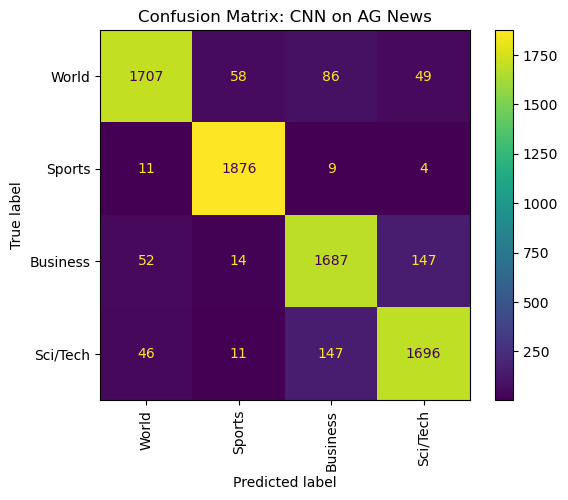


Transformer Classification Report
              precision    recall  f1-score   support

       World       0.92      0.88      0.90      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.86      0.83      0.84      1900
    Sci/Tech       0.85      0.88      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600

Transformer Accuracy: 0.8931578947368422


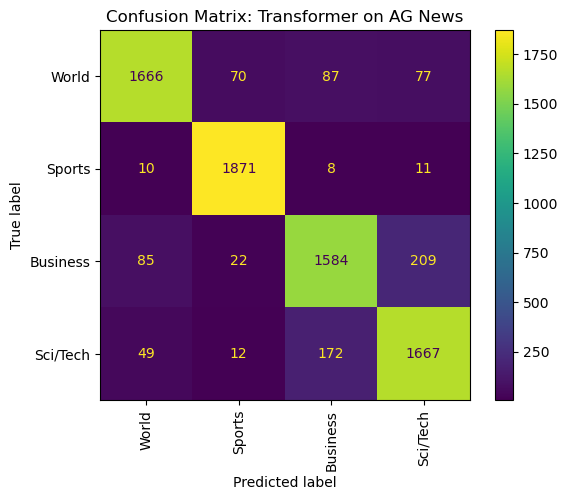

In [25]:
target_names = ["World", "Sports", "Business", "Sci/Tech"]

print("\nCNN Classification Report")
print(classification_report(cnn_test["y_true"], cnn_test["y_pred"], target_names=target_names))

# CNN
cm_cnn = confusion_matrix(cnn_test["y_true"], cnn_test["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: CNN on AG News")
plt.show()

# DistilBert
pred_output = trainer.predict(tokenized_test)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids

print("\nTransformer Classification Report")
print(classification_report(y_true, y_pred, target_names=target_names))

print("Transformer Accuracy:", accuracy_score(y_true, y_pred))
cm_tf = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tf, display_labels=target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: Transformer on AG News")
plt.show()

In [23]:
texts = [item["text"] for item in test_ds_hf]

y_true = ablation_cnn_test["y_true"]
y_pred = ablation_cnn_test["y_pred"]

true_labels = [target_names[i] for i in y_true]
pred_labels = [target_names[i] for i in y_pred]

min_len = min(len(test_ds_hf), len(y_true), len(y_pred))
texts = [item["text"] for item in test_ds_hf[:min_len]]
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

true_labels = [target_names[i] for i in y_true]
pred_labels = [target_names[i] for i in y_pred]

df_predictions = pd.DataFrame({
    "text": texts,
    "true_label": true_labels,
    "pred_label": pred_labels
})

errors = df_predictions[df_predictions["true_label"] != df_predictions["pred_label"]]

print(f"Total Errors: {len(errors)}")
print("Displaying first 20 misclassifications:")

pd.set_option("display.max_colwidth", 150)
display(errors.head(20))

NameError: name 'ablation_cnn_test' is not defined

In [ ]:
res_cnn = {
    "name": "CNN (dropout=0.4)",
    "hist": cnn_hist
}

# Second model = {
#    "name": "CNN (dropout=0.3)",
#    "hist": cnn_hist_three_dropout
# }

def plot_learning_curves(results, key: str, title: str, ylabel: str):
    plt.figure()
    for res in results:
        hist = res["hist"]
        epochs = [h["epoch"] for h in hist]
        vals = [h[key] for h in hist]
        plt.plot(epochs, vals, label=res["name"])
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

plot_learning_curves([res_cnn, res_cnn_three_dropout], "val_loss", "Validation loss", "loss")
plot_learning_curves([res_cnn, res_cnn_three_dropout], "val_f1", "Validation macro F1", "macro F1")
